# OPERA DISP-S1 Displacement Time Series Analysis

This notebook demonstrates:
- Searching and downloading OPERA DISP-S1 products from NASA Earthdata
- Processing ministack structure for time series
- Applying quality masks
- Visualizing displacement

**Environment**: `conda activate asf_env`

**Data Source**: NASA Earthdata CMR (not ASF)

## 1. Import Libraries

In [25]:
# Install missing packages if needed
import sys
import subprocess

try:
    import h5netcdf
    print("✅ h5netcdf already installed")
except ImportError:
    print("📦 Installing h5netcdf...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "h5netcdf", "-q"])
    print("✅ h5netcdf installed!")

✅ h5netcdf already installed


In [26]:
import earthaccess
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import rasterio
import geopandas as gpd
from shapely.geometry import box
import pandas as pd
from pathlib import Path
import h5netcdf  # For reading OPERA NetCDF files
from pyproj import Transformer
import re
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Authenticate with NASA Earthdata

OPERA DISP-S1 is distributed via NASA Earthdata (not ASF).

Requires `~/.netrc` file with:
```
machine urs.earthdata.nasa.gov
login YOUR_USERNAME
password YOUR_PASSWORD
```
Then: `chmod 600 ~/.netrc`

In [27]:
# Authenticate (uses ~/.netrc automatically)
auth = earthaccess.login()

if auth:
    print("✅ Successfully authenticated with NASA Earthdata!")
    print(f"   Session established")
else:

    print("❌ Authentication failed. Check ~/.netrc file.")    

✅ Successfully authenticated with NASA Earthdata!
   Session established


## 3. Define Area of Interest

**Known DISP-S1 coverage areas**:
- Los Angeles: `(-118.3, 33.7, -118.1, 33.9)` [ASF serach portal](https://search.asf.alaska.edu/#/?zoom=7.123&center=-114.225,31.278&polygon=POLYGON((-118.3%2033.7,-118.1%2033.7,-118.1%2033.9,-118.3%2033.9,-118.3%2033.7))&dataset=OPERA-S1&productTypes=DISP-S1&resultsLoaded=true&granule=OPERA_L3_DISP-S1_IW_F18904_VV_20250620T135131Z_20250918T135239Z_v1.0_20260123T064647Z&maxResults=250)
- San Francisco Bay: `(-122.5, 37.3, -122.0, 37.8)`[ASF serach portal](https://search.asf.alaska.edu/#/?zoom=8.774&center=-120.884,36.543&polygon=POLYGON((-122.5%2037.3,-122%2037.3,-122%2037.8,-122.5%2037.8,-122.5%2037.3))&dataset=OPERA-S1&productTypes=DISP-S1&resultsLoaded=true&granule=OPERA_L3_DISP-S1_IW_F09156_VV_20250730T020738Z_20251109T020635Z_v1.0_20251125T161611Z&maxResults=250)
- Central Valley: `(-121.5, 36.5, -121.0, 37.0)`[ASF serach portal](https://search.asf.alaska.edu/#/?zoom=8.928&center=-121.145,35.830&polygon=POLYGON((-121.5%2036.5,-121%2036.5,-121%2037,-121.5%2037,-121.5%2036.5))&dataset=OPERA-S1&productTypes=DISP-S1&resultsLoaded=true&granule=OPERA_L3_DISP-S1_IW_F09156_VV_20250730T020738Z_20251109T020635Z_v1.0_20251125T161611Z&maxResults=250)

📍 AOI: (-118.3, 33.7, -118.1, 33.9)
💾 Output: /mnt/data/opera_disp_s1


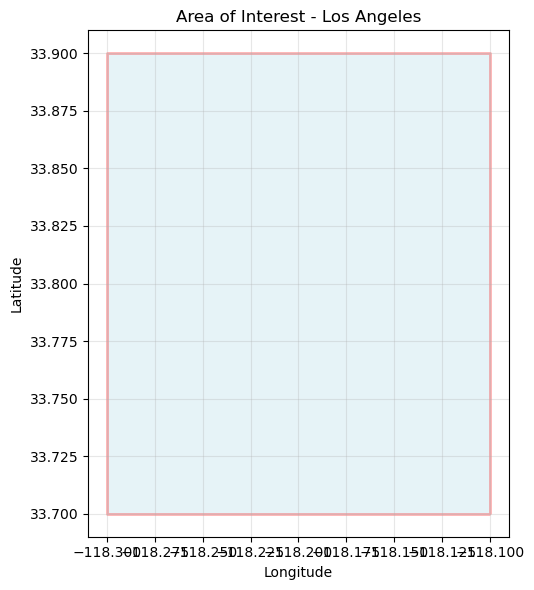

In [28]:
# Define AOI - Los Angeles area
aoi_bbox = (-118.3, 33.7, -118.1, 33.9)  # (min_lon, min_lat, max_lon, max_lat)

# Output directory
output_dir = Path('/mnt/data/opera_disp_s1')
output_dir.mkdir(parents=True, exist_ok=True)

print(f"📍 AOI: {aoi_bbox}")
print(f"💾 Output: {output_dir}")

# Visualize AOI
fig, ax = plt.subplots(figsize=(8, 6))
aoi_geom = box(*aoi_bbox)
gdf = gpd.GeoDataFrame([1], geometry=[aoi_geom], crs='EPSG:4326')
gdf.plot(ax=ax, facecolor='lightblue', edgecolor='red', linewidth=2, alpha=0.3)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Area of Interest - Los Angeles')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Search for OPERA DISP-S1 Products

Product short name: `OPERA_L3_DISP-S1_V1`

In [29]:
# Search for OPERA DISP-S1 products
print("Searching for OPERA DISP-S1 products...")

results = earthaccess.search_data(
    short_name='OPERA_L3_DISP-S1_V1',
    bounding_box=aoi_bbox,
    temporal=('2020-01-01', '2025-12-31')
)

print(f"\n✅ Found {len(results)} OPERA DISP-S1 granules!")

if len(results) == 0:
    print("\n⚠️  No products found. Try:")
    print("  1. Different AOI (Los Angeles, SF Bay Area)")
    print("  2. Broader temporal range")
    print("  3. Check product availability at: https://search.earthdata.nasa.gov")
else:
    # Show first few results
    print("\nFirst 5 products:")
    for i, granule in enumerate(results[:5]):
        print(f"  {i+1}. {granule['umm']['GranuleUR']}")

Searching for OPERA DISP-S1 products...

✅ Found 943 OPERA DISP-S1 granules!

First 5 products:
  1. OPERA_L3_DISP-S1_IW_F16940_VV_20191026T014929Z_20200205T015008Z_v1.0_20250411T020030Z
  2. OPERA_L3_DISP-S1_IW_F16940_VV_20191026T014929Z_20200106T014927Z_v1.0_20250411T020030Z
  3. OPERA_L3_DISP-S1_IW_F16940_VV_20191026T014929Z_20200211T014926Z_v1.0_20250411T020030Z
  4. OPERA_L3_DISP-S1_IW_F16940_VV_20191026T014929Z_20200130T014926Z_v1.0_20250411T020030Z
  5. OPERA_L3_DISP-S1_IW_F16940_VV_20191026T014929Z_20200118T014927Z_v1.0_20250411T020030Z


## 5. Inspect Product Metadata

Extract frame IDs, dates, and orbit directions.

In [30]:
if len(results) > 0:
    # Parse granule information
    granule_info = []
    
    for granule in results:
        granule_id = granule['umm']['GranuleUR']
        
        # Extract frame ID: OPERA_L3_DISP-S1_IW_F{frame}_...
        import re
        frame_match = re.search(r'_F(\d+)_', granule_id)
        frame = frame_match.group(1) if frame_match else 'Unknown'
        
        # Extract dates
        date_matches = re.findall(r'(\d{8}T\d{6}Z)', granule_id)
        
        # Extract orbit direction if available
        orbit = 'ASC' if 'ASCENDING' in granule_id.upper() or '_A_' in granule_id else \
                'DESC' if 'DESCENDING' in granule_id.upper() or '_D_' in granule_id else 'Unknown'
        
        granule_info.append({
            'granule_id': granule_id,
            'frame': frame,
            'orbit': orbit,
            'ref_date': date_matches[0] if len(date_matches) > 0 else None,
            'acq_date': date_matches[1] if len(date_matches) > 1 else None
        })
    
    df = pd.DataFrame(granule_info)
    
    print(f"\n📊 Product Summary:")
    print(f"  Total products: {len(df)}")
    print(f"  Unique frames: {df['frame'].nunique()}")
    print(f"\nProducts per frame:")
    print(df.groupby('frame').size().sort_values(ascending=False))
    
    print(f"\nProducts per orbit direction:")
    print(df.groupby('orbit').size())
    
    # Select best frame (most acquisitions)
    best_frame = df.groupby('frame').size().idxmax()
    print(f"\n🎯 Best frame (most acquisitions): {best_frame}")
    print(f"   Number of acquisitions: {len(df[df['frame'] == best_frame])}")


📊 Product Summary:
  Total products: 943
  Unique frames: 4

Products per frame:
frame
16940    245
18904    239
36540    237
36539    222
dtype: int64

Products per orbit direction:
orbit
Unknown    943
dtype: int64

🎯 Best frame (most acquisitions): 16940
   Number of acquisitions: 245


## 5b. Check File Sizes and Total Volume

Extract file sizes from metadata to estimate download volume.

In [31]:
if len(results) > 0:
    # Extract file sizes from metadata
    file_info = []
    
    for granule in results:
        granule_id = granule['umm']['GranuleUR']
        
        # Get file size (in bytes)
        size_bytes = 0
        if 'DataGranule' in granule['umm'] and 'ArchiveAndDistributionInformation' in granule['umm']['DataGranule']:
            for item in granule['umm']['DataGranule']['ArchiveAndDistributionInformation']:
                if 'SizeInBytes' in item:
                    size_bytes += item['SizeInBytes']
        
        # Extract frame
        frame_match = re.search(r'_F(\d+)_', granule_id)
        frame = frame_match.group(1) if frame_match else 'Unknown'
        
        file_info.append({
            'granule_id': granule_id,
            'frame': frame,
            'size_mb': size_bytes / (1024 * 1024)
        })
    
    file_df = pd.DataFrame(file_info)
    
    # Calculate total volume
    total_gb = file_df['size_mb'].sum() / 1024
    
    print(f"\n💾 Download Volume Analysis:")
    print(f"  Total products: {len(file_df)}")
    print(f"  Total size: {total_gb:.2f} GB")
    print(f"  Average file size: {file_df['size_mb'].mean():.2f} MB")
    print(f"  Min file size: {file_df['size_mb'].min():.2f} MB")
    print(f"  Max file size: {file_df['size_mb'].max():.2f} MB")
    
    # Volume per frame
    print(f"\n📊 Volume by frame:")
    frame_volumes = file_df.groupby('frame')['size_mb'].agg(['count', 'sum'])
    frame_volumes['sum_gb'] = frame_volumes['sum'] / 1024
    frame_volumes = frame_volumes.sort_values('sum_gb', ascending=False)
    for frame, row in frame_volumes.head(5).iterrows():
        print(f"  Frame {frame}: {row['count']} files, {row['sum_gb']:.2f} GB")
    
    # Store for later use
    file_sizes_df = file_df
else:
    print("No results to analyze. Run search first.")



💾 Download Volume Analysis:
  Total products: 943
  Total size: 269.36 GB
  Average file size: 292.49 MB
  Min file size: 96.37 MB
  Max file size: 412.81 MB

📊 Volume by frame:
  Frame 16940: 245.0 files, 92.50 GB
  Frame 18904: 239.0 files, 88.62 GB
  Frame 36540: 237.0 files, 65.14 GB
  Frame 36539: 222.0 files, 23.10 GB


## 5c. Analyze Ministack Structure (No Download Required)

Parse filenames to understand temporal structure and overlaps.


📅 Temporal Analysis:
  Date range: 2020-01-05 to 2025-09-18
  Unique ministacks (reference dates): 48
  Unique acquisition dates: 481

🗂️  Ministack structure:

  Frame 16940: 16 ministacks
    Ministack 2019-10-26: 5 acquisitions
    Ministack 2020-02-11: 15 acquisitions
    Ministack 2020-05-23: 15 acquisitions
    Ministack 2020-08-21: 15 acquisitions
    Ministack 2020-11-19: 15 acquisitions
    ... and 11 more ministacks

  Frame 18904: 16 ministacks
    Ministack 2019-12-25: 14 acquisitions
    Ministack 2020-03-30: 15 acquisitions
    Ministack 2020-06-28: 15 acquisitions
    Ministack 2020-10-02: 15 acquisitions
    Ministack 2020-12-31: 15 acquisitions
    ... and 11 more ministacks

  Frame 36539: 15 ministacks
    Ministack 2019-12-06: 12 acquisitions
    Ministack 2020-03-11: 15 acquisitions
    Ministack 2020-06-09: 15 acquisitions
    Ministack 2020-09-07: 15 acquisitions
    Ministack 2020-12-06: 15 acquisitions
    ... and 10 more ministacks


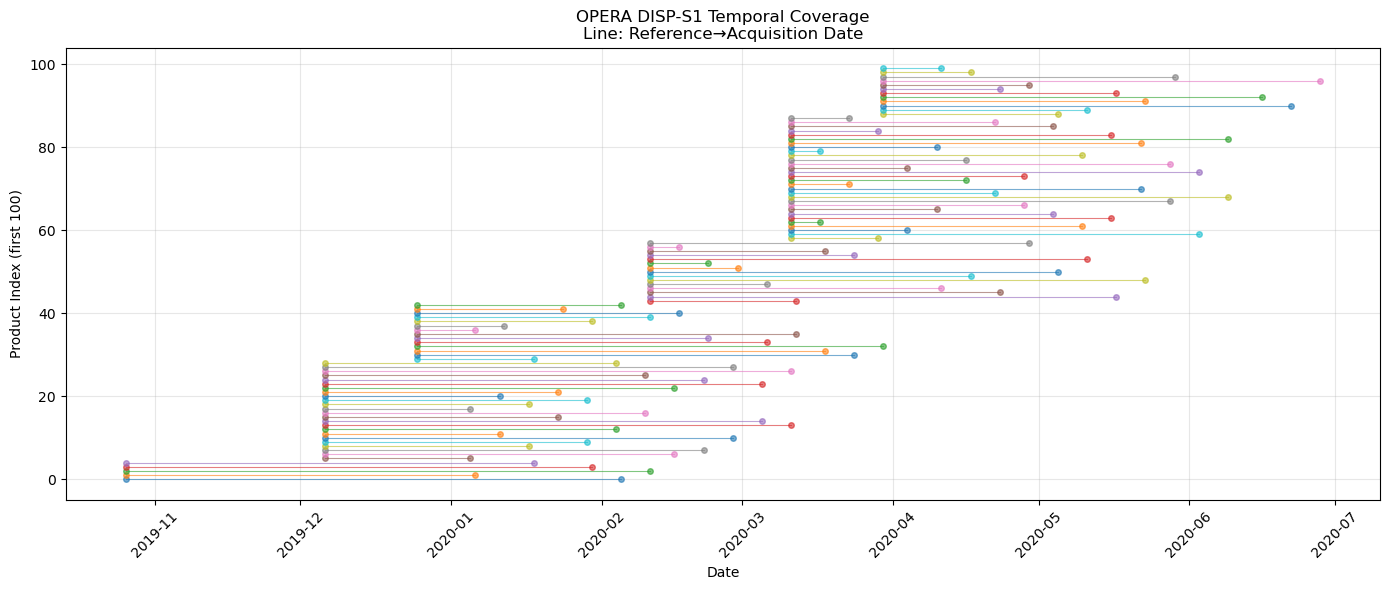


✅ Analyzed 943 products WITHOUT downloading!


In [32]:
if len(results) > 0:
    # Parse all filenames for temporal information
    temporal_info = []
    
    for granule in results:
        granule_id = granule['umm']['GranuleUR']
        
        # Extract frame ID
        frame_match = re.search(r'_F(\d+)_', granule_id)
        frame = frame_match.group(1) if frame_match else 'Unknown'
        
        # Extract dates: OPERA_L3_DISP-S1_IW_F{frame}_VV_{ref_date}_{acq_date}_...
        # Dates are in format: YYYYMMDDTHHMMSSZ
        date_matches = re.findall(r'(\d{8})T\d{6}Z', granule_id)
        
        if len(date_matches) >= 2:
            ref_date = pd.to_datetime(date_matches[0], format='%Y%m%d')
            acq_date = pd.to_datetime(date_matches[1], format='%Y%m%d')
            
            temporal_info.append({
                'granule_id': granule_id,
                'frame': frame,
                'ref_date': ref_date,
                'acq_date': acq_date,
                'ministack_id': date_matches[0]  # Reference date identifies ministack
            })
    
    temporal_df = pd.DataFrame(temporal_info)
    
    if len(temporal_df) > 0:
        print(f"\n📅 Temporal Analysis:")
        print(f"  Date range: {temporal_df['acq_date'].min().date()} to {temporal_df['acq_date'].max().date()}")
        print(f"  Unique ministacks (reference dates): {temporal_df['ministack_id'].nunique()}")
        print(f"  Unique acquisition dates: {temporal_df['acq_date'].nunique()}")
        
        # Show ministacks
        print(f"\n🗂️  Ministack structure:")
        ministack_counts = temporal_df.groupby(['frame', 'ministack_id']).size().reset_index(name='n_acquisitions')
        
        for frame in ministack_counts['frame'].unique()[:3]:  # Show first 3 frames
            frame_data = ministack_counts[ministack_counts['frame'] == frame]
            print(f"\n  Frame {frame}: {len(frame_data)} ministacks")
            for _, row in frame_data.head(5).iterrows():
                ref = pd.to_datetime(row['ministack_id'], format='%Y%m%d').date()
                print(f"    Ministack {ref}: {row['n_acquisitions']} acquisitions")
            if len(frame_data) > 5:
                print(f"    ... and {len(frame_data)-5} more ministacks")
        
        # Visualize temporal coverage
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # Plot each acquisition as a line from ref to acq date
        for idx, row in temporal_df.head(100).iterrows():  # Limit for visibility
            ax.plot([row['ref_date'], row['acq_date']], [idx, idx], 
                   'o-', markersize=4, linewidth=0.8, alpha=0.6)
        
        ax.set_xlabel('Date')
        ax.set_ylabel('Product Index (first 100)')
        ax.set_title('OPERA DISP-S1 Temporal Coverage\nLine: Reference→Acquisition Date')
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Store for later use
        temporal_analysis_df = temporal_df
        
        print(f"\n✅ Analyzed {len(temporal_df)} products WITHOUT downloading!")
    else:
        print("⚠️  Could not parse temporal information from filenames")
else:
    print("No results to analyze. Run search first.")


## 5d. Select Products for Download

Choose specific frame and limit download based on your needs.

In [33]:
if len(results) > 0 and 'best_frame' in locals() and 'temporal_analysis_df' in locals():
    # Filter to best frame
    frame_products = temporal_analysis_df[temporal_analysis_df['frame'] == best_frame].copy()
    frame_products = frame_products.sort_values('acq_date')
    
    print(f"📦 Frame {best_frame} Download Plan:")
    print(f"  Total available: {len(frame_products)} products")
    
    # Check orbit direction for this frame
    if 'df' in locals():
        frame_orbits = df[df['frame'] == best_frame]['orbit'].value_counts()
        print(f"\n🛰️  Orbit Direction:")
        for orbit, count in frame_orbits.items():
            print(f"  {orbit}: {count} products ({count/len(frame_products)*100:.1f}%)")
        
        if len(frame_orbits) > 1:
            print(f"\n⚠️  Mixed orbit directions detected!")
            print(f"   Consider filtering to single orbit for consistent geometry")
        else:
            print(f"\n✅ All products are {frame_orbits.index[0]} orbit")
    
    # Calculate size for this frame
    if 'file_sizes_df' in locals():
        frame_sizes = file_sizes_df[file_sizes_df['frame'] == best_frame]
        frame_total_gb = frame_sizes['size_mb'].sum() / 1024
        print(f"\n  Total size: {frame_total_gb:.2f} GB")
    
    # Show ministack breakdown
    ministack_summary = frame_products.groupby('ministack_id').agg({
        'acq_date': ['min', 'max', 'count']
    })
    ministack_summary.columns = ['first_acq', 'last_acq', 'n_acq']
    ministack_summary = ministack_summary.reset_index()
    
    print(f"\n  Ministacks: {len(ministack_summary)}")
    print(f"\n  First 5 ministacks:")
    for _, row in ministack_summary.head(5).iterrows():
        ref_date = pd.to_datetime(row['ministack_id'], format='%Y%m%d').date()
        print(f"    {ref_date}: {row['n_acq']} acquisitions ({row['first_acq'].date()} to {row['last_acq'].date()})")
    
    # Suggest download strategy
    print(f"\n💡 Download Strategy Options:")
    print(f"  1. All products: {len(frame_products)} files (~{frame_total_gb:.1f} GB)")
    print(f"  2. First ministack: ~{len(frame_products) // len(ministack_summary)} files (~{frame_total_gb / len(ministack_summary):.1f} GB)")
    print(f"  3. Recent data (last 20): 20 files (~{20 * (frame_total_gb / len(frame_products)):.1f} GB)")
    
    # Option to filter by orbit direction
    filter_orbit = None  # Set to 'ASC' or 'DESC' to filter, None for all
    
    if filter_orbit:
        print(f"\n🔍 Filtering to {filter_orbit} orbit only...")
        frame_orbit_mask = df['frame'] == best_frame
        orbit_mask = df['orbit'] == filter_orbit
        filtered_granules = df[frame_orbit_mask & orbit_mask]['granule_id'].tolist()
        frame_products_filtered = frame_products[frame_products['granule_id'].isin(filtered_granules)]
        
        if 'file_sizes_df' in locals():
            filtered_size_gb = file_sizes_df[file_sizes_df['granule_id'].isin(filtered_granules)]['size_mb'].sum() / 1024
            print(f"   Filtered to {len(frame_products_filtered)} products ({filtered_size_gb:.2f} GB)")
        
        selected_granule_ids = filtered_granules
    else:
        # Get all granule IDs for selected frame
        selected_granule_ids = frame_products['granule_id'].tolist()
    
    selected_results = [g for g in results if g['umm']['GranuleUR'] in selected_granule_ids]
    
    print(f"\n✅ Ready to download {len(selected_results)} products for frame {best_frame}")
    if filter_orbit:
        print(f"   Orbit: {filter_orbit} only")
    print(f"   💡 To filter by orbit, set filter_orbit='ASC' or 'DESC' in this cell")
    print(f"   Modify the next cell to change download limits")
    
else:
    print("Run previous cells first to analyze products")


📦 Frame 16940 Download Plan:
  Total available: 245 products

🛰️  Orbit Direction:
  Unknown: 245 products (100.0%)

✅ All products are Unknown orbit

  Total size: 92.50 GB

  Ministacks: 16

  First 5 ministacks:
    2019-10-26: 5 acquisitions (2020-01-06 to 2020-02-11)
    2020-02-11: 15 acquisitions (2020-02-17 to 2020-05-23)
    2020-05-23: 15 acquisitions (2020-05-29 to 2020-08-21)
    2020-08-21: 15 acquisitions (2020-08-27 to 2020-11-19)
    2020-11-19: 15 acquisitions (2020-11-25 to 2021-02-23)

💡 Download Strategy Options:
  1. All products: 245 files (~92.5 GB)
  2. First ministack: ~15 files (~5.8 GB)
  3. Recent data (last 20): 20 files (~7.6 GB)

✅ Ready to download 245 products for frame 16940
   💡 To filter by orbit, set filter_orbit='ASC' or 'DESC' in this cell
   Modify the next cell to change download limits


## 6. Download Products

Download the selected products. Adjust `max_download` based on your needs and storage.

In [ ]:
if 'selected_results' in locals() and len(selected_results) > 0:
    # Set download limit
    max_download = min(20, len(selected_results))  # Change 20 to download more/fewer
    
    print(f"📥 Downloading {max_download} of {len(selected_results)} products...")
    
    # Calculate download size
    if 'file_sizes_df' in locals():
        download_products = [g['umm']['GranuleUR'] for g in selected_results[:max_download]]
        download_size_mb = file_sizes_df[
            file_sizes_df['granule_id'].isin(download_products)
        ]['size_mb'].sum()
        print(f"   Estimated size: {download_size_mb/1024:.2f} GB")
    
    print(f"   Destination: {output_dir}")
    print(f"\n⏳ Starting download...")
    
    # Re-authenticate to ensure valid session
    auth = earthaccess.login()
    if not auth:
        print("❌ Authentication failed. Check ~/.netrc file.")
        downloaded_files = []
    else:
        print(f"   ✅ Authentication confirmed")
        print(f"   Progress will be shown for each file...\n")
        
        # Download with progress bar
        downloaded_files = earthaccess.download(
            selected_results[:max_download],
            str(output_dir),
            threads=4  # Parallel downloads with progress tracking
        )
    
    print(f"\n✅ Downloaded {len(downloaded_files)} files!")

    print(f"\nFiles:")    downloaded_files = []

    for f in downloaded_files[:5]:    print("No products to download. Run previous cells first.")

        print(f"  {Path(f).name}")else:

    if len(downloaded_files) > 5:        print(f"  ... and {len(downloaded_files)-5} more")

📥 Downloading 20 of 245 products...
   Estimated size: 7.75 GB
   Destination: /mnt/data/opera_disp_s1

⏳ Starting download...
   Progress will be shown for each file...



'NoneType' object has no attribute 'get': You must call earthaccess.login() before you can download data



✅ Downloaded 0 files!

Files:


## 7. Load and Stack with xarray

Load all NetCDF files and stack them into a time series.

In [ ]:
if downloaded_files:
    # Find all .nc files
    nc_files = sorted([f for f in downloaded_files if str(f).endswith('.nc')])
    
    print(f"Loading {len(nc_files)} NetCDF files...")
    
    # Load with xarray
    def preprocess(ds):
        # Add time coordinate from filename
        filename = Path(ds.encoding['source']).name
        dates = re.findall(r'(\d{8})', filename)
        if len(dates) >= 2:
            acq_date = datetime.strptime(dates[1], '%Y%m%d')
            ds = ds.assign_coords(time=acq_date)
        return ds
    
    # Stack all files
    ds = xr.open_mfdataset(
        nc_files,
        combine='nested',
        concat_dim='time',
        preprocess=preprocess,
        engine='h5netcdf'
    )
    
    print(f"\n✅ Loaded dataset!")
    print(f"\nDataset info:")
    print(f"  Dimensions: {dict(ds.dims)}")
    print(f"  Variables: {list(ds.data_vars)}")
    print(f"  Time range: {ds.time.min().values} to {ds.time.max().values}")
else:
    print("No files to load. Download data first.")

## 8. Visualize Displacement

Plot displacement maps with quality masking.

In [ ]:
if 'ds' in locals():
    # Select last time step
    disp = ds['unwrapped_phase'].isel(time=-1)  # or 'displacement' or 'short_wavelength_displacement'
    
    # Apply quality mask if available
    if 'conncomp' in ds:
        mask = ds['conncomp'].isel(time=-1) > 0
        disp = disp.where(mask)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    im = disp.plot(ax=ax, cmap='RdBu_r', vmin=-0.1, vmax=0.1, add_colorbar=True)
    ax.set_title(f'OPERA DISP-S1 Displacement\nDate: {ds.time.isel(time=-1).values}')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\nDisplacement statistics:")
    print(f"  Min: {float(disp.min())*100:.2f} cm")
    print(f"  Max: {float(disp.max())*100:.2f} cm")
    print(f"  Mean: {float(disp.mean())*100:.2f} cm")
    print(f"  Std: {float(disp.std())*100:.2f} cm")
else:
    print("Dataset not loaded. Run previous cells first.")

## Summary

This notebook demonstrates the complete workflow for OPERA DISP-S1 data:
1. ✅ Authentication with NASA Earthdata
2. ✅ Search using `earthaccess` (not ASF)
3. ✅ Download granules
4. ✅ Load and stack with xarray
5. ✅ Visualize displacement

Next steps:
- Chain ministacks for continuous time series
- Apply additional quality masks
- Extract point time series
- Calculate velocities